<a href="https://colab.research.google.com/github/thowfeekkr/ict_assignment/blob/main/Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Case Study: Olympic Medal Data Analysis

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PART 1 — Data Understanding


Q1. Load the dataset.

In [43]:
olympic_data=pd.read_csv('/content/athlete_events - medal.csv')

# Display first 5 rows.
olympic_data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [44]:
#Print number of rows and columns.
print("Rows and colunms are:", olympic_data.shape)

Rows and colunms are: (246864, 15)


In [45]:
#Display column names.
olympic_data.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

Q2. Check data types.

In [46]:
#Which columns are numerical?
olympic_data.select_dtypes(include='number')

,ID,Age,Height,Weight,Year
0,1,24.0,180.0,80.0,1992.0
1,2,23.0,170.0,60.0,2012.0
2,3,24.0,NaN,NaN,1920.0
3,4,34.0,NaN,NaN,1900.0
4,5,21.0,185.0,82.0,1988.0
...,...,...,...,...,...
246859,123601,19.0,165.0,58.0,1964.0
246860,123601,23.0,165.0,58.0,1968.0
246861,123601,23.0,165.0,58.0,1968.0
246862,123602,27.0,185.0,78.0,1992.0


In [47]:
olympic_data.select_dtypes(include='object')

,Name,Sex,Team,NOC,Games,Season,City,Sport,Event,Medal
0,A Dijiang,M,China,CHN,1992 Summer,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,A Lamusi,M,China,CHN,2012 Summer,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,Gunnar Nielsen Aaby,M,Denmark,DEN,1920 Summer,Summer,Antwerpen,Football,Football Men's Football,NaN
3,Edgar Lindenau Aabye,M,Denmark/Sweden,DEN,1900 Summer,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,Christine Jacoba Aaftink,F,Netherlands,NED,1988 Winter,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...
246859,Nataliya Andreyevna Ustinova,F,Soviet Union,URS,1964 Summer,Summer,Tokyo,Swimming,Swimming Women's 4 x 100 metres Medley Relay,Bronze
246860,Nataliya Andreyevna Ustinova,F,Soviet Union,URS,1968 Summer,Summer,Mexico City,Swimming,Swimming Women's 100 metres Freestyle,NaN
246861,Nataliya Andreyevna Ustinova,F,Soviet Union,URS,1968 Summer,Summer,Mexico City,Swimming,Swimming Women's 4 x 100 metres Freestyle Relay,NaN
246862,Tetiana Illivna Ustiuzhanina,F,Unified Team,EUN,1992 Summer,Summer,Barcelona,Rowing,Rowing Women's Quadruple Sculls,Bronze


In [48]:
#Find number of missing values in each column
olympic_data.isna().sum()

,0
ID,0
Name,0
Sex,0
Age,8667
Height,54813
Weight,57347
Team,0
NOC,0
Games,0
Year,1


In [49]:
#Why does the Medal column have many missing values?
print(olympic_data['Medal'].unique())


[nan 'Gold' 'Bronze' 'Silver']


In [50]:
medal_winners = olympic_data[olympic_data['Medal'].notna()]

medal_winners

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014.0,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948.0,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246836,123589,Luis Mara Usoz Quintana,M,27.0,169.0,68.0,Spain,ESP,1960 Summer,1960.0,Summer,Roma,Hockey,Hockey Men's Hockey,Bronze
246839,123590,Pablo Usoz Ciriza,M,27.0,178.0,78.0,Spain,ESP,1996 Summer,1996.0,Summer,Atlanta,Hockey,Hockey Men's Hockey,Silver
246846,123595,scar Alfredo Ustari,M,22.0,183.0,84.0,Argentina,ARG,2008 Summer,2008.0,Summer,Beijing,Football,Football Men's Football,Gold
246859,123601,Nataliya Andreyevna Ustinova,F,19.0,165.0,58.0,Soviet Union,URS,1964 Summer,1964.0,Summer,Tokyo,Swimming,Swimming Women's 4 x 100 metres Medley Relay,Bronze


In [51]:
olympic_data=olympic_data.drop(olympic_data[olympic_data['Medal']=='nan'].index)
olympic_data

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246859,123601,Nataliya Andreyevna Ustinova,F,19.0,165.0,58.0,Soviet Union,URS,1964 Summer,1964.0,Summer,Tokyo,Swimming,Swimming Women's 4 x 100 metres Medley Relay,Bronze
246860,123601,Nataliya Andreyevna Ustinova,F,23.0,165.0,58.0,Soviet Union,URS,1968 Summer,1968.0,Summer,Mexico City,Swimming,Swimming Women's 100 metres Freestyle,NaN
246861,123601,Nataliya Andreyevna Ustinova,F,23.0,165.0,58.0,Soviet Union,URS,1968 Summer,1968.0,Summer,Mexico City,Swimming,Swimming Women's 4 x 100 metres Freestyle Relay,NaN
246862,123602,Tetiana Illivna Ustiuzhanina,F,27.0,185.0,78.0,Unified Team,EUN,1992 Summer,1992.0,Summer,Barcelona,Rowing,Rowing Women's Quadruple Sculls,Bronze


In [52]:
olympic_data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


Q5. Total Medal Count

In [70]:
#Find total medals won by each country.

olympic_data.groupby('Team')['Medal'].count()

,Medal
Team,
30. Februar,0
A North American Team,3
Acipactli,0
Acturus,0
Afghanistan,2
...,...
Zambia,2
Zefyros,0
Zimbabwe,20


In [72]:
#PART 3 — Country Analysis
#Q5. Total Medal Count
#Find total medals won by each country.
#Display top 10 countries.
medal_won = olympic_data.groupby('Team')['Medal'].count()
top_10_countries = medal_won.sort_values(ascending=False).head(10)
display(top_10_countries)

,Medal
Team,
United States,4793
Soviet Union,2226
Germany,1723
Great Britain,1545
France,1497
Italy,1425
Sweden,1342
Australia,1205
Canada,1140


/tmp/ipykernel_515/2883127505.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')


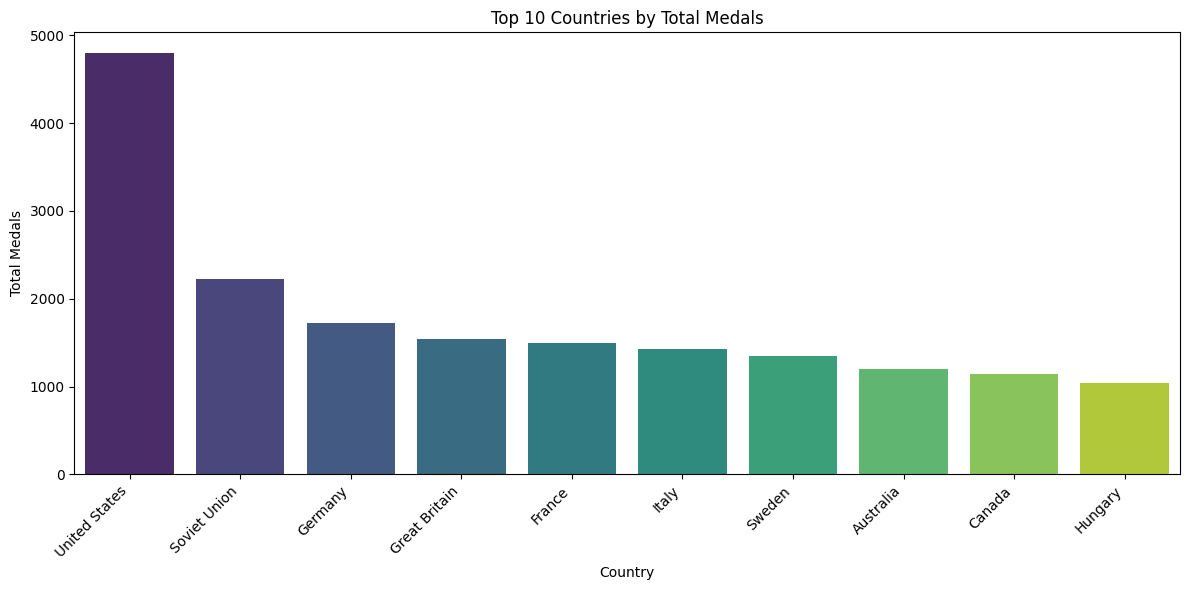

In [75]:
#Q6. Visualize Top 10 Countries
# Create a bar chart of top 10 countries by total medals.

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')
plt.title('Top 10 Countries by Total Medals')
plt.xlabel('Country')
plt.ylabel('Total Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.show()


In [78]:
# Filter for Gold medals
gold_medals = olympic_data[olympic_data['Medal'] == 'Gold']

# Count Gold medals by Team
gold_medal_counts = gold_medals.groupby('Team')['Medal'].count()

# Find top 10 countries with most Gold medals
top_10_gold_countries = gold_medal_counts.sort_values(ascending=False).head(10)
display(top_10_gold_countries)

,Medal
Team,
United States,2264
Soviet Union,965
Germany,586
Italy,494
Great Britain,477
France,442
Sweden,416
Hungary,402
Canada,391


/tmp/ipykernel_515/304919088.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_gold_countries.index, y=top_10_gold_countries.values, palette='YlOrBr')


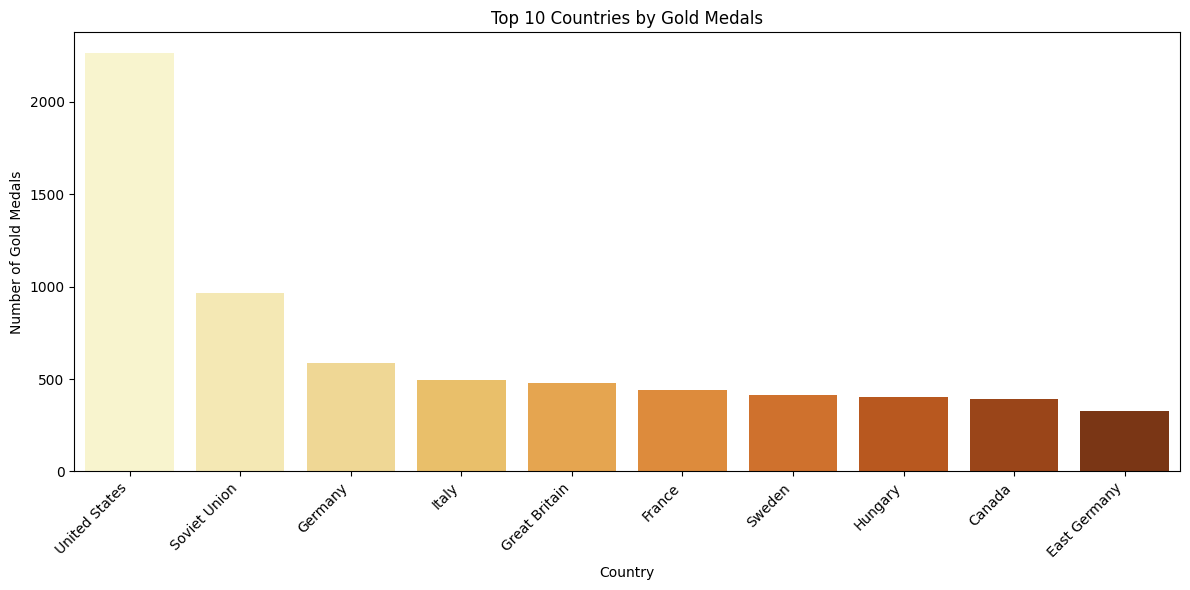

In [82]:
# Plot a bar chart of top 10 countries by Gold medals
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_gold_countries.index, y=top_10_gold_countries.values, palette='YlOrBr')
plt.title('Top 10 Countries by Gold Medals')
plt.xlabel('Country')
plt.ylabel('Number of Gold Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_515/879100999.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=medal_winners, palette={'M': 'skyblue', 'F': 'lightcoral'})


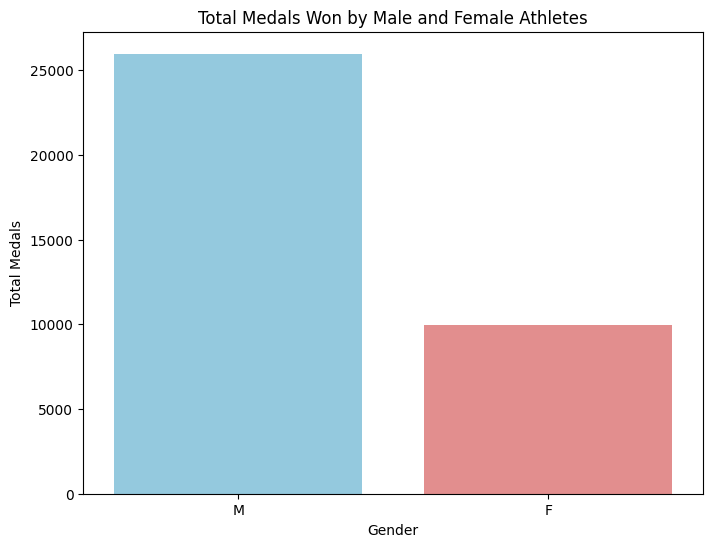

In [83]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', data=medal_winners, palette={'M': 'skyblue', 'F': 'lightcoral'})
plt.title('Total Medals Won by Male and Female Athletes')
plt.xlabel('Gender')
plt.ylabel('Total Medals')
plt.show()

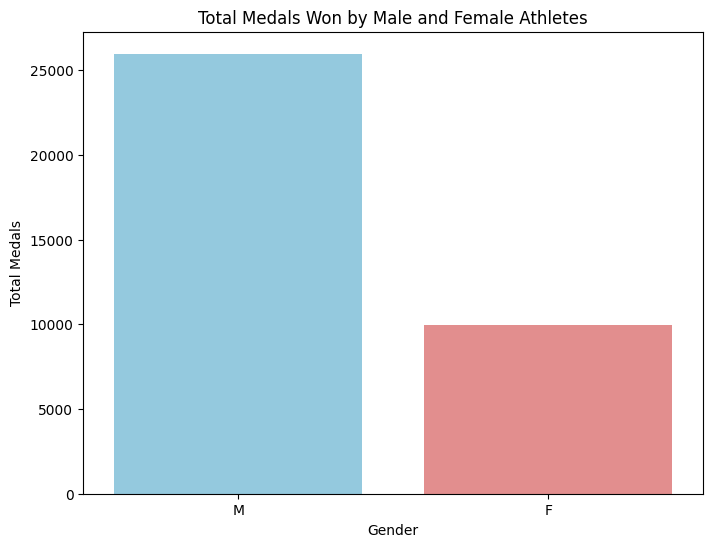

In [84]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Sex', data=medal_winners, palette={'M': 'skyblue', 'F': 'lightcoral'}, legend=False)
plt.title('Total Medals Won by Male and Female Athletes')
plt.xlabel('Gender')
plt.ylabel('Total Medals')
plt.show()

In [85]:
medals_by_year_sex = medal_winners.groupby(['Year', 'Sex'])['Medal'].count().reset_index()
medals_by_year_sex.rename(columns={'Medal': 'Total Medals'}, inplace=True)
medals_by_year_sex.head()

,Year,Sex,Total Medals
0,1896.0,M,129
1,1900.0,F,12
2,1900.0,M,543
3,1904.0,F,9
4,1904.0,M,422


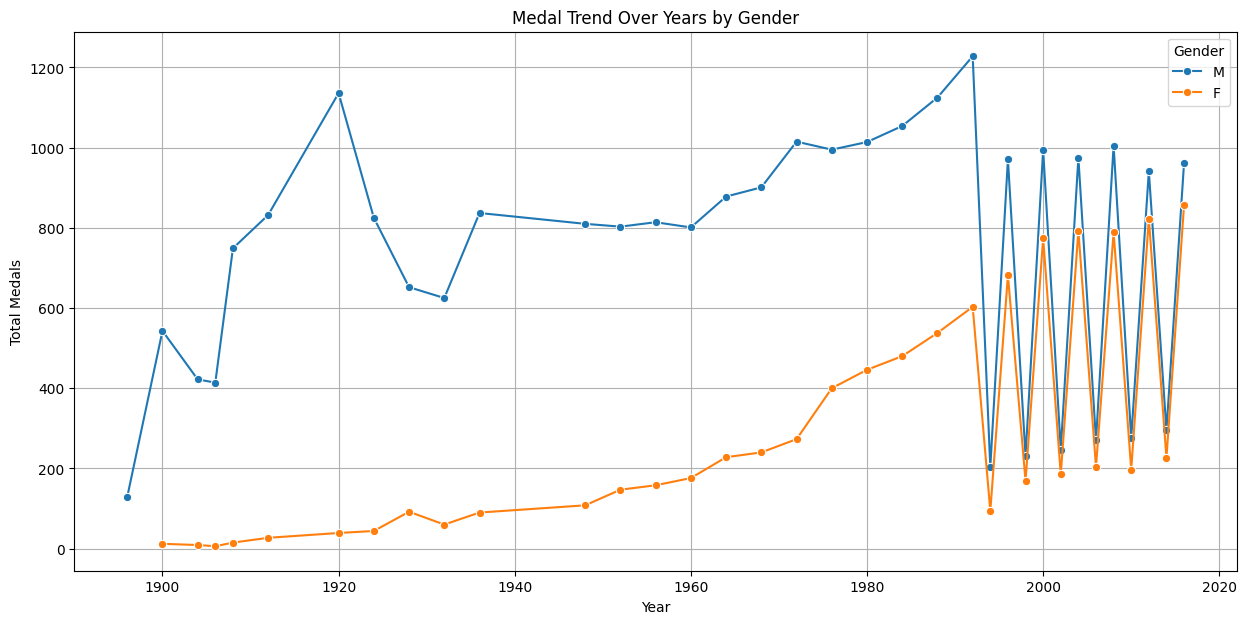

In [86]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='Year', y='Total Medals', hue='Sex', data=medals_by_year_sex, marker='o')
plt.title('Medal Trend Over Years by Gender')
plt.xlabel('Year')
plt.ylabel('Total Medals')
plt.grid(True)
plt.legend(title='Gender')
plt.show()

In [87]:
sport_medal_counts = medal_winners.groupby('Sport')['Medal'].count()
top_10_sports = sport_medal_counts.sort_values(ascending=False).head(10)
display(top_10_sports)

,Medal
Sport,
Athletics,3654
Swimming,2717
Rowing,2683
Gymnastics,2049
Fencing,1599
Football,1439
Ice Hockey,1414
Hockey,1366
Wrestling,1178


/tmp/ipykernel_515/934815842.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_sports.index, y=top_10_sports.values, palette='crest')


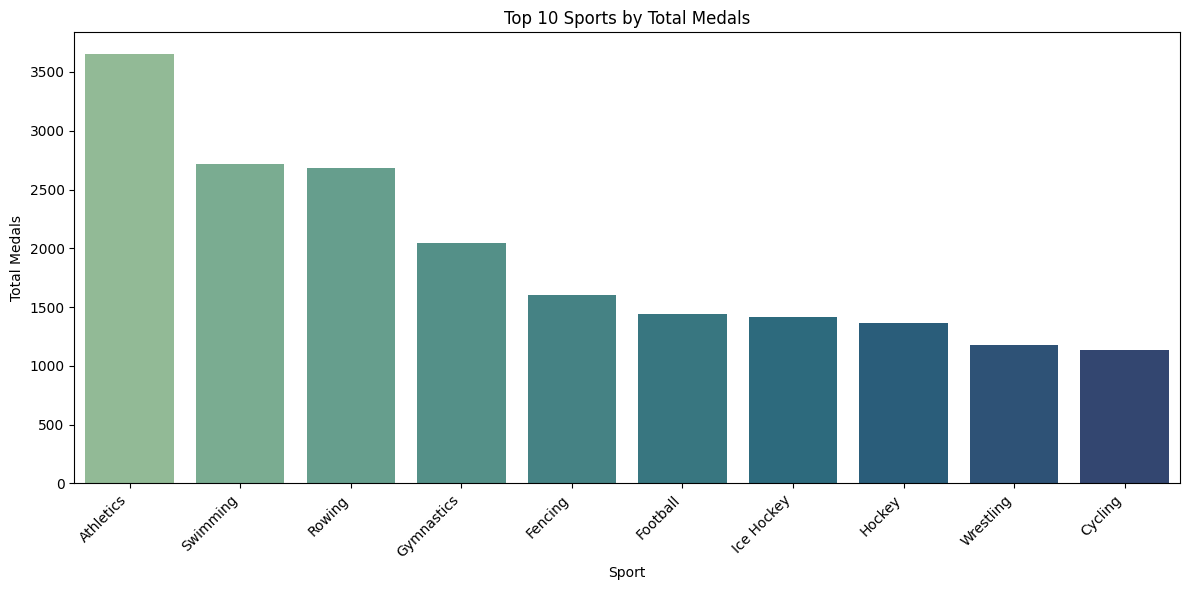

In [88]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_sports.index, y=top_10_sports.values, palette='crest')
plt.title('Top 10 Sports by Total Medals')
plt.xlabel('Sport')
plt.ylabel('Total Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

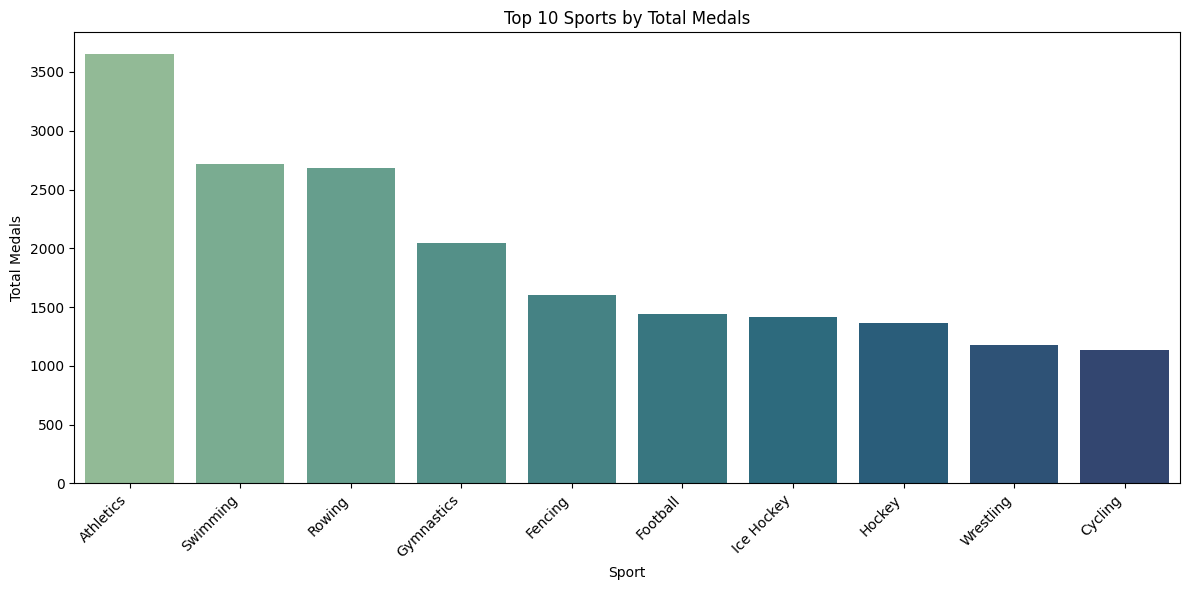

In [89]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_sports.index, y=top_10_sports.values, palette='crest', hue=top_10_sports.index, legend=False)
plt.title('Top 10 Sports by Total Medals')
plt.xlabel('Sport')
plt.ylabel('Total Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [90]:
gold_medals_only = medal_winners[medal_winners['Medal'] == 'Gold']
sport_gold_medal_counts = gold_medals_only.groupby('Sport')['Medal'].count()
most_gold_sport = sport_gold_medal_counts.idxmax()
max_gold_medals = sport_gold_medal_counts.max()

print(f"The sport with the most Gold medals is '{most_gold_sport}' with {max_gold_medals} Gold medals.")

The sport with the most Gold medals is 'Athletics' with 1230 Gold medals.


In [91]:
medals_per_year = medal_winners.groupby('Year')['Medal'].count().reset_index()
medals_per_year.rename(columns={'Medal': 'Total Medals'}, inplace=True)
medals_per_year.head()

,Year,Total Medals
0,1896.0,129
1,1900.0,555
2,1904.0,431
3,1906.0,420
4,1908.0,764


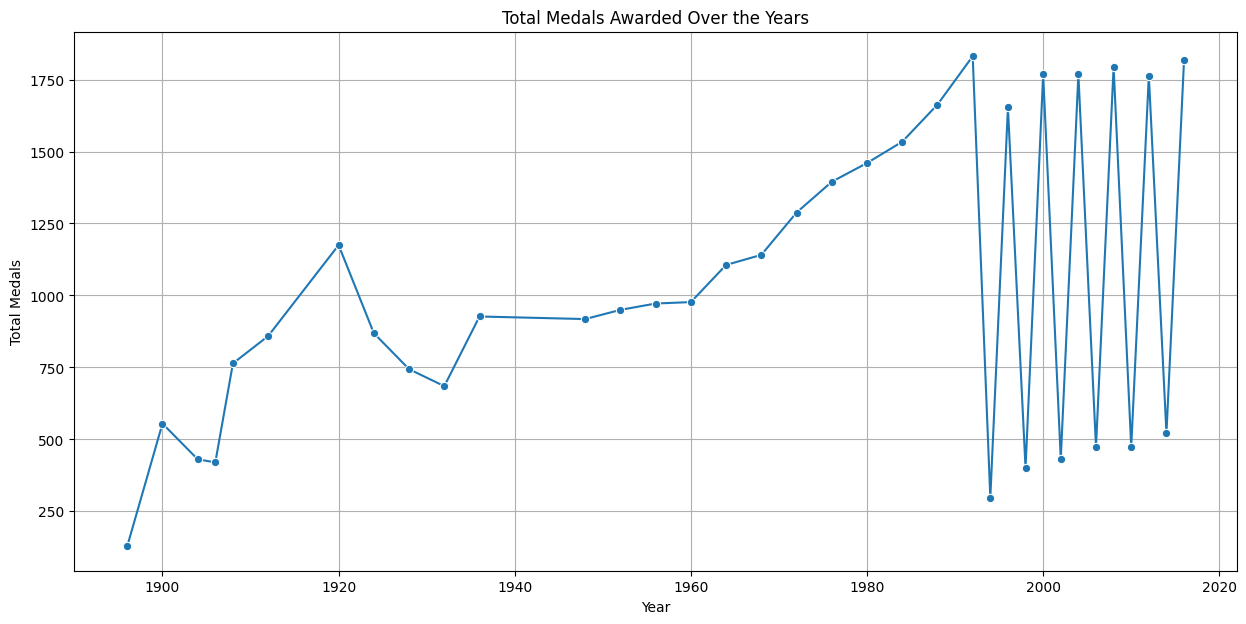

In [92]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='Year', y='Total Medals', data=medals_per_year, marker='o')
plt.title('Total Medals Awarded Over the Years')
plt.xlabel('Year')
plt.ylabel('Total Medals')
plt.grid(True)
plt.show()

In [93]:
year_with_max_medals = medals_per_year.loc[medals_per_year['Total Medals'].idxmax()]
max_medals_year = year_with_max_medals['Year']
max_medals_count = year_with_max_medals['Total Medals']

print(f"The year with the highest number of medals awarded is {int(max_medals_year)} with {int(max_medals_count)} medals.")

The year with the highest number of medals awarded is 1992 with 1831 medals.


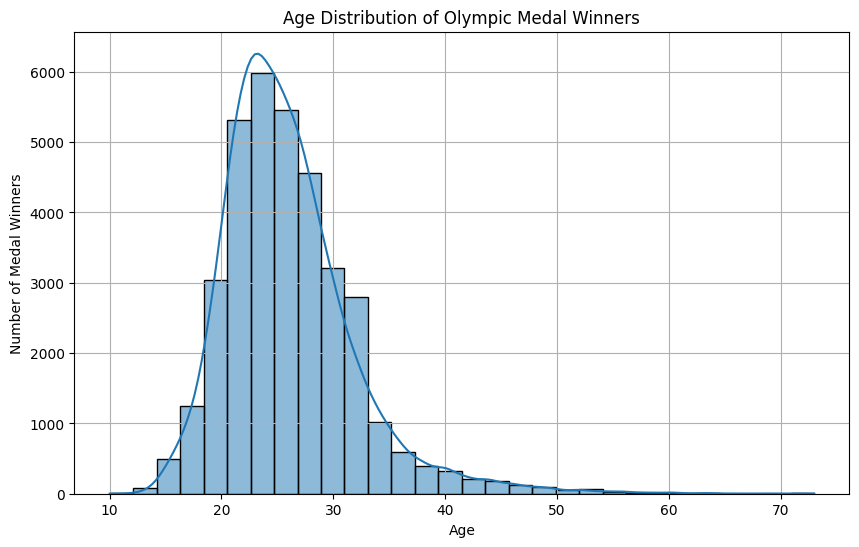

In [94]:
plt.figure(figsize=(10, 6))
sns.histplot(medal_winners['Age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution of Olympic Medal Winners')
plt.xlabel('Age')
plt.ylabel('Number of Medal Winners')
plt.grid(True)
plt.show()

In [95]:
average_age_by_medal = medal_winners.groupby('Medal')['Age'].mean()
display(average_age_by_medal)

,Age
Medal,
Bronze,25.902074
Gold,25.906690
Silver,26.027022


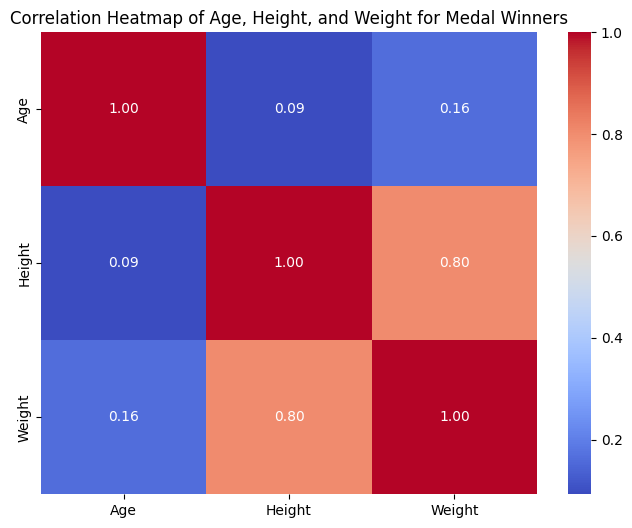

In [96]:
numerical_cols = ['Age', 'Height', 'Weight']
correlation_matrix = medal_winners[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Age, Height, and Weight for Medal Winners')
plt.show()

In [97]:
usa_medals = medal_winners[medal_winners['Team'] == 'United States']
usa_medals.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
186,84,Stephen Anthony Abas,M,26.0,165.0,55.0,United States,USA,2004 Summer,2004.0,Summer,Athina,Wrestling,"Wrestling Men's Featherweight, Freestyle",Silver
278,145,Jeremy Abbott,M,28.0,175.0,70.0,United States,USA,2014 Winter,2014.0,Winter,Sochi,Figure Skating,Figure Skating Mixed Team,Bronze
283,150,Margaret Ives Abbott (-Dunne),F,23.0,NaN,NaN,United States,USA,1900 Summer,1900.0,Summer,Paris,Golf,Golf Women's Individual,Gold
286,153,Monica Cecilia Abbott,F,23.0,191.0,88.0,United States,USA,2008 Summer,2008.0,Summer,Beijing,Softball,Softball Women's Softball,Silver
311,165,Nia Nicole Abdallah,F,20.0,175.0,56.0,United States,USA,2004 Summer,2004.0,Summer,Athina,Taekwondo,Taekwondo Women's Featherweight,Silver


Best sport

In [98]:
total_usa_medals = len(usa_medals)

usa_gold_medals = usa_medals[usa_medals['Medal'] == 'Gold']
total_usa_gold_medals = len(usa_gold_medals)

usa_sport_medal_counts = usa_medals.groupby('Sport')['Medal'].count()
usa_best_sport = usa_sport_medal_counts.idxmax()
usa_best_sport_medals = usa_sport_medal_counts.max()

print(f"Total medals won by United States: {total_usa_medals}")
print(f"Total gold medals won by United States: {total_usa_gold_medals}")
print(f"Best performing sport for United States: {usa_best_sport} with {usa_best_sport_medals} medals.")

Total medals won by United States: 4793
Total gold medals won by United States: 2264
Best performing sport for United States: Athletics with 999 medals.


In [99]:
usa_medals_per_year = usa_medals.groupby('Year')['Medal'].count().reset_index()
usa_medals_per_year.rename(columns={'Medal': 'Total Medals'}, inplace=True)
usa_medals_per_year.head()

,Year,Total Medals
0,1896.0,20
1,1900.0,44
2,1904.0,173
3,1906.0,24
4,1908.0,63


Medal trend over years




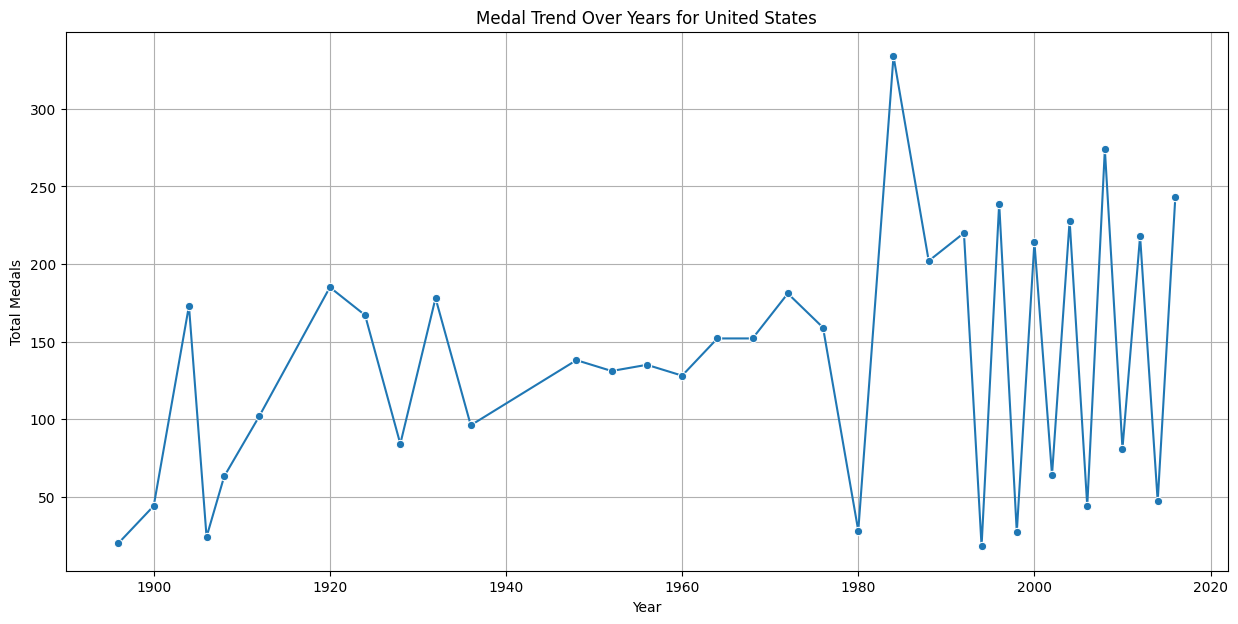

In [100]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='Year', y='Total Medals', data=usa_medals_per_year, marker='o')
plt.title('Medal Trend Over Years for United States')
plt.xlabel('Year')
plt.ylabel('Total Medals')
plt.grid(True)
plt.show()

In [101]:
athletics_medals = medal_winners[medal_winners['Sport'] == 'Athletics']
athletics_medals.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
163,67,Mariya Vasilyevna Abakumova (-Tarabina),F,22.0,179.0,80.0,Russia,RUS,2008 Summer,2008.0,Summer,Beijing,Athletics,Athletics Women's Javelin Throw,Silver
191,86,Jos Manuel Abascal Gmez,M,26.0,182.0,67.0,Spain,ESP,1984 Summer,1984.0,Summer,Los Angeles,Athletics,"Athletics Men's 1,500 metres",Bronze
620,359,Andrey Khakimovich Abduvaliyev,M,26.0,190.0,125.0,Unified Team,EUN,1992 Summer,1992.0,Summer,Barcelona,Athletics,Athletics Men's Hammer Throw,Gold
655,379,Addis Abebe,M,21.0,160.0,50.0,Ethiopia,ETH,1992 Summer,1992.0,Summer,Barcelona,Athletics,"Athletics Men's 10,000 metres",Bronze
720,411,Gezahgne Abera,M,22.0,166.0,58.0,Ethiopia,ETH,2000 Summer,2000.0,Summer,Sydney,Athletics,Athletics Men's Marathon,Gold


#Q18. Sport Deep Dive
Which country dominates?

In [102]:
athletics_team_medals = athletics_medals.groupby('Team')['Medal'].count()
dominating_country_athletics = athletics_team_medals.idxmax()
max_medals_athletics = athletics_team_medals.max()

print(f"The dominating country in Athletics is '{dominating_country_athletics}' with {max_medals_athletics} medals.")

The dominating country in Athletics is 'United States' with 999 medals.


Gender participation trend


In [103]:
athletics_medals_by_year_sex = athletics_medals.groupby(['Year', 'Sex'])['Medal'].count().reset_index()
athletics_medals_by_year_sex.rename(columns={'Medal': 'Total Medals'}, inplace=True)
athletics_medals_by_year_sex.head()

,Year,Sex,Total Medals
0,1896.0,M,35
1,1900.0,M,76
2,1904.0,M,71
3,1906.0,M,65
4,1908.0,M,93


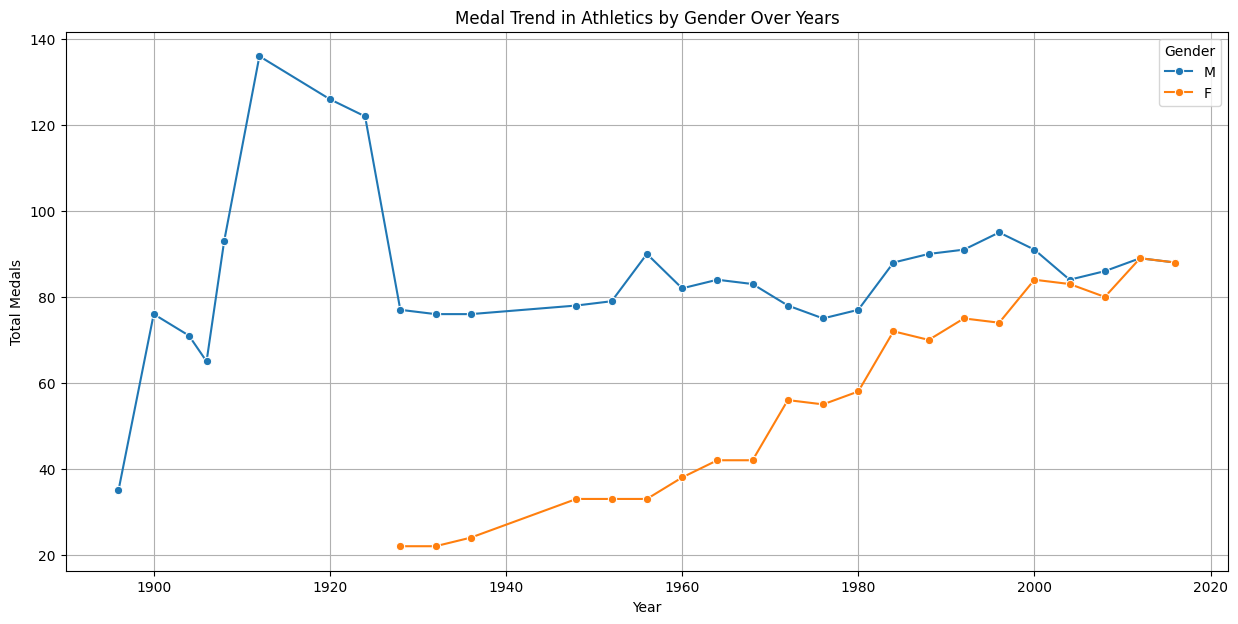

In [104]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='Year', y='Total Medals', hue='Sex', data=athletics_medals_by_year_sex, marker='o')
plt.title('Medal Trend in Athletics by Gender Over Years')
plt.xlabel('Year')
plt.ylabel('Total Medals')
plt.grid(True)
plt.legend(title='Gender')
plt.show()

Average age of winners




In [105]:
average_age_athletics = athletics_medals['Age'].dropna().mean()
print(f"The average age of medal winners in Athletics is {average_age_athletics:.2f} years.")

The average age of medal winners in Athletics is 25.02 years.


Q19. Top 5 Youngest Gold Medalists


In [106]:
gold_medalists = medal_winners[medal_winners['Medal'] == 'Gold']
youngest_gold_medalists = gold_medalists.sort_values(by='Age', ascending=True).head(5)
display(youngest_gold_medalists)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
78544,39866,Marjorie Gestring (-Redlick),F,13.0,NaN,NaN,United States,USA,1936 Summer,1936.0,Summer,Berlin,Diving,Diving Women's Springboard,Gold
73581,37398,Fu Mingxia,F,13.0,160.0,48.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Diving,Diving Women's Platform,Gold
52010,26731,Donna Elizabeth de Varona (-Pinto),F,13.0,168.0,61.0,United States,USA,1960 Summer,1960.0,Summer,Roma,Swimming,Swimming Women's 4 x 100 metres Freestyle Relay,Gold
200704,100797,Aileen Muriel Riggin (-Soule),F,13.0,142.0,NaN,United States,USA,1920 Summer,1920.0,Summer,Antwerpen,Diving,Diving Women's Springboard,Gold
119277,60384,Kim Yun-Mi,F,13.0,160.0,48.0,South Korea,KOR,1994 Winter,1994.0,Winter,Lillehammer,Short Track Speed Skating,"Short Track Speed Skating Women's 3,000 metres...",Gold


Q20. Medal Ratio


In [107]:
top_5_countries = top_10_countries.head(5)

gold_medals_top_5 = gold_medals_only[gold_medals_only['Team'].isin(top_5_countries.index)]
gold_medal_counts_top_5 = gold_medals_top_5.groupby('Team')['Medal'].count()

medal_ratio = gold_medal_counts_top_5 / top_5_countries

print("Gold to Total Medal Ratio for Top 5 Countries:")
display(medal_ratio.sort_values(ascending=False))

Gold to Total Medal Ratio for Top 5 Countries:


,Medal
Team,
United States,0.472356
Soviet Union,0.433513
Germany,0.340104
Great Britain,0.308738
France,0.295257
